In [2]:
import numpy as np
import pandas as pd
import requests
import time 

In [3]:
#importing the countries
url="https://api.worldbank.org/countries?format=json&per_page=300"

In [4]:
response=requests.get(url)
response.status_code

200

In [5]:
data=response.json()
print(len(data))


2


In [6]:
data[0]

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 295}

In [7]:
countries=data[1]
df=pd.DataFrame(countries)

In [8]:
df["region"][0]
df["adminregion"][0]
df["incomeLevel"][0]
df["lendingType"][0]


{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}

In [9]:
df["region"]=df["region"].apply(lambda x:x['value'])

In [10]:
df["incomeLevel"]=df["incomeLevel"].apply(lambda x : x["value"])

In [11]:
df["lendingType"]=df["lendingType"].apply(lambda x : x["value"])

In [18]:
df.head()


,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,"{'id': '', 'iso2code': '', 'value': ''}",High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...",Low income,IDA,Kabul,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
4,AFW,ZI,Africa Western and Central,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,


In [19]:
df.rename(columns={"iso2Code":"country_id"},inplace=True)

In [20]:
df2=df

In [21]:
df2=df2.drop(columns=["adminregion","capitalCity"])

In [22]:
df2.tail()

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
290,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
291,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
292,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
293,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982
294,ZWE,ZW,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [23]:
#indicators

base_url = "https://api.worldbank.org/v2/indicators?format=json"

indicator_resp=requests.get(base_url) 

indicator_data=indicator_resp.json()
indicator_data[0]
df_i=pd.DataFrame(indicator_data[1])
df_i.head()

,id,name,unit,source,sourceNote,sourceOrganization,topics
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of data from Nation...,"[{'id': '11', 'value': 'Poverty '}]"
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"


In [24]:
indicator_data[0]

#0- meta data
#1- actual data


{'page': 1, 'pages': 591, 'per_page': '50', 'total': 29544}

In [18]:
all_dfs=[]
for i in range(1,200):
    url=f"https://api.worldbank.org/v2/indicators?format=json&per_page=500&page={i}"
    response=requests.get(url)
    if response.status_code==200:
        data=response.json()
        if len(data)<2:
            print(f"error no data this page")
        indicators=data[1]
        df=pd.DataFrame([{"id":item["id"],"name":item["name"] }for item in indicators])

        all_dfs.append(df)
        print(f"page{i}:{len(df)} in indicators collected")
    else:
        print(f"failed to fatech the page{i} : {response.status_code}")  

page1:500 in indicators collected
page2:500 in indicators collected
page3:500 in indicators collected
page4:500 in indicators collected
page5:500 in indicators collected
page6:500 in indicators collected
page7:500 in indicators collected
page8:500 in indicators collected
page9:500 in indicators collected
page10:500 in indicators collected
page11:500 in indicators collected
page12:500 in indicators collected
page13:500 in indicators collected
page14:500 in indicators collected
page15:500 in indicators collected
page16:500 in indicators collected
page17:500 in indicators collected
page18:500 in indicators collected
page19:500 in indicators collected
page20:500 in indicators collected
page21:500 in indicators collected
page22:500 in indicators collected
page23:500 in indicators collected
page24:500 in indicators collected
page25:500 in indicators collected
page26:500 in indicators collected
page27:500 in indicators collected
page28:500 in indicators collected
page29:500 in indicators coll

In [60]:
final_df=pd.concat(all_dfs,ignore_index=True)

In [61]:
final_df

,id,name
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day)
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day)
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day)
...,...,...
29539,ytil_some_dfcl_all,Youth idle rate (% of persons with some degree...
29540,ytil_some_dfcl_fem,Youth idle rate (% of female persons with some...
29541,ytil_some_dfcl_male,Youth idle rate (% of male persons with some d...
29542,ytil_some_dfcl_rur,Youth idle rate (% of persons living in rural ...


In [62]:
final_df.to_csv("final.csv")

In [25]:
indicators = {
    "economic_activity_growth": [
        "NY.GDP.MKTP.KD.ZG",  # GDP growth (annual %)
        "NY.GDP.PCAP.CD",     # GDP per capita (current US$)
    ],

    "labour_market_indicators": [
        "SL.UEM.TOTL.ZS",     # Unemployment, total (% of total labor force) (modeled ILO estimate)
        "SL.UEM.1524.ZS",     # Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)
        "SL.TLF.TOTL.IN",     # Labor force, total
    ],

    "trade_globalisation": [
        "NE.EXP.GNFS.CD",     # Exports of goods and services (current US$)
        "NE.IMP.GNFS.CD",     # Imports of goods and services (current US$)
    ],

    "poverty_inequality": [
        "SI.POV.NAHC",         # Poverty headcount ratio at national poverty lines (% of population)
        "SI.POV.GINI",         # Gini index
    ],

    "environmental_indicators": [
        "EG.FEC.RNEW.ZS",     # Renewable energy consumption (% of total final energy consumption)
        "AG.LND.FRST.ZS",     # Forest area (% of land area)
    ],

    "health_indicators": [
        "SP.DYN.LE00.IN",     # Life expectancy at birth, total (years)
        "SP.DYN.IMRT.IN",     # Mortality rate, infant (per 1,000 live births)
        "SH.H2O.BASW.ZS",     # People using at least basic drinking water services (% of population)
        "SH.XPD.CHEX.GD.ZS",   # Current health expenditure (% of GDP)
        "SH.IMM.IDPT",         # Immunization, DPT (% of children ages 12-23 months)
        "SH.IMM.MEAS",         # Immunization, measles (% of children ages 12-23 months)
        "SH.MMR.RISK.ZS",      # Lifetime risk of maternal death (%)
        "SH.DTH.COMM.ZS",      # Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)
        "SH.TBS.INCD",         # Incidence of tuberculosis (per 100,000 people)
        "SH.STA.BRTC.ZS",      # Births attended by skilled health staff (% of total)
        "SH.STA.MMRT",         # Maternal mortality ratio (modeled estimate, per 100,000 live births)
        "SP.POP.0014.TO.ZS",   # Population ages 0-14 (% of total population)
        "SH.HIV.INCD.ZS",      # Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)
    ],

    "technology_indicators": [
        "IT.NET.USER.ZS",      # Individuals using the Internet (% of population)
        "IT.CEL.SETS.P2",      # Mobile cellular subscriptions (per 100 people)
    ],
}

In [26]:
url="https://api.worldbank.org/countries/all/indicators/NY.GDP.PCAP.CD?format=json"
respons=requests.get(url)
data=respons.json()
total_page=data[0]["pages"]
record=data[1]
df=pd.json_normalize(record)
df.head(2)

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,AFE,2025,1722.385620,,,1,NY.GDP.PCAP.CD,GDP per capita (current US$),ZH,Africa Eastern and Southern
1,AFE,2024,1628.227289,,,1,NY.GDP.PCAP.CD,GDP per capita (current US$),ZH,Africa Eastern and Southern


In [27]:
import time

In [28]:
base_url = "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"

category_dataframes={}
for category,indicator in indicators.items():
    print(f"Fatch intofmation for category:{category}")
    category_df=[]
    
    for indicator_code in indicator:        
        print(f"fatching indicator: {indicator_code}")
        page=1
        
        while True:
            url=base_url.format(indicator_code,page)
            response=requests.get(url)
        
            if response.status_code!=200:
                print(f"No Data For Indicator {indicator_code} on page {page}")
        
            data=response.json()
            if len(data)<2:
                print(f"Failed at page {page}")
                break
            total_page=data[0]["pages"]
            record=data[1]
            df=pd.json_normalize(record)

            df=df[["date","value","indicator.id","indicator.value","country.id","country.value"]].rename(
                columns={
                "indicator.id":"indicator_id",
                "indicator.value":"indicator_value",
                "country.id":"country_id",
                "country.value":"country_value",
                "date":"year"
            })
            df=df[df["year"].astype(int)>2015]
            category_df.append(df)

            if page>=total_page:
                break
            else:
                page+=1
                time.sleep(0.3)

    if category_df:
        combined_df=pd.concat(category_df,ignore_index=True)
        category_dataframes[category] = combined_df
        print(f"Total raws collectted for {category} : {len(combined_df)}")
    else:
        print(f"No data collected for {category}")

print("Data Fatching complete")
            

              
    
    

Fatch intofmation for category:economic_activity_growth
fatching indicator: NY.GDP.MKTP.KD.ZG
fatching indicator: NY.GDP.PCAP.CD
Total raws collectted for economic_activity_growth : 5300
Fatch intofmation for category:labour_market_indicators
fatching indicator: SL.UEM.TOTL.ZS
fatching indicator: SL.UEM.1524.ZS
fatching indicator: SL.TLF.TOTL.IN
Total raws collectted for labour_market_indicators : 7950
Fatch intofmation for category:trade_globalisation
fatching indicator: NE.EXP.GNFS.CD
fatching indicator: NE.IMP.GNFS.CD
Total raws collectted for trade_globalisation : 5300
Fatch intofmation for category:poverty_inequality
fatching indicator: SI.POV.NAHC
fatching indicator: SI.POV.GINI


C:\Users\HIMAN\AppData\Local\Temp\ipykernel_5088\444370144.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df=pd.concat(category_df,ignore_index=True)


Total raws collectted for poverty_inequality : 5300
Fatch intofmation for category:environmental_indicators
fatching indicator: EG.FEC.RNEW.ZS
fatching indicator: AG.LND.FRST.ZS
Total raws collectted for environmental_indicators : 5300
Fatch intofmation for category:health_indicators
fatching indicator: SP.DYN.LE00.IN
fatching indicator: SP.DYN.IMRT.IN
fatching indicator: SH.H2O.BASW.ZS
fatching indicator: SH.XPD.CHEX.GD.ZS
fatching indicator: SH.IMM.IDPT
fatching indicator: SH.IMM.MEAS
fatching indicator: SH.MMR.RISK.ZS
fatching indicator: SH.TBS.INCD
fatching indicator: SH.STA.BRTC.ZS
fatching indicator: SH.STA.MMRT
fatching indicator: SP.POP.0014.TO.ZS
fatching indicator: SH.HIV.INCD.ZS
Total raws collectted for health_indicators : 34450
Fatch intofmation for category:technology_indicators
fatching indicator: IT.NET.USER.ZS
fatching indicator: IT.CEL.SETS.P2
Total raws collectted for technology_indicators : 5300
Data Fatching complete


In [198]:
economic_activity = category_dataframes.get("economic_activity_growth",pd.DataFrame)

labour_activity = category_dataframes.get("labour_market_indicators",pd.DataFrame)

trade_globalisation = category_dataframes.get("trade_globalisation",pd.DataFrame)

poverty_inequality_activity = category_dataframes.get("poverty_inequality",pd.DataFrame)

environmental_indicators = category_dataframes.get("environmental_indicators",pd.DataFrame)

health = category_dataframes.get("health_indicators",pd.DataFrame)

technology_indicators = category_dataframes.get("technology_indicators",pd.DataFrame)


In [14]:
health = category_dataframes.get("health_indicators",pd.DataFrame)
health.head(10)

NameError: name 'category_dataframes' is not defined

In [15]:
df2.head(10)


NameError: name 'df2' is not defined

In [201]:
health = category_dataframes["health_indicators"][["year","value","indicator_id","indicator_value","country_id","country_value"]].copy()

country_info = df2[["country_id","id","name","region","incomeLevel","lendingType","longitude","latitude"]].copy()

health = health.merge(country_info,on="country_id",how="inner")

In [202]:
health.head()

,year,value,indicator_id,indicator_value,country_id,country_value,id,name,region,incomeLevel,lendingType,longitude,latitude
0,2025,NaN,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,65.349930,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,2023,65.146228,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,2022,64.487152,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
4,2021,62.979999,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,AFE,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [203]:
#margeing the table
economic = pd.merge(economic_activity,df2,on="country_id",how="inner")

labour_market = pd.merge(labour_activity,df2,on="country_id",how="inner")

trade = pd.merge(trade_globalisation,df2,on="country_id",how="inner")

poverty_inequality = pd.merge(poverty_inequality_activity,df2,on="country_id",how="inner")

environmental = pd.merge(environmental_indicators,df2,on="country_id",how="inner")

health = pd.merge(health,df2,on="country_id",how="inner")

technology = pd.merge(technology_indicators,df2,on="country_id",how="inner")


In [204]:

technology.drop(columns=["indicator_id","id","name"],inplace=True)

In [205]:
economic.drop(columns=["indicator_id","id","name"],inplace=True)
labour_market.drop(columns=["indicator_id","id","name"],inplace=True)
trade.drop(columns=["indicator_id","id","name"],inplace=True)
poverty_inequality.drop(columns=["indicator_id","id","name"],inplace=True)
environmental.drop(columns=["indicator_id","id","name"],inplace=True)
health.drop(columns=["indicator_id","id","name"],inplace=True)

In [226]:
health.head(2)


,year,value,indicator_value,country_id,country_value,region,incomeLevel,lendingType,longitude,latitude
0,2025,NaN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,65.34993,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [207]:
#df.raname(columns="iso2Code":"country_id",inplace=True)
df.head(2)

,id,country_id,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,"{'id': '', 'iso2code': '', 'value': ''}",High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,


In [208]:
technology.head(2)


,year,value,indicator_value,country_id,country_value,region,incomeLevel,lendingType,longitude,latitude
0,2025,30.4,Individuals using the Internet (% of population),ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,28.8,Individuals using the Internet (% of population),ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [209]:
economic.head(2)

,year,value,indicator_value,country_id,country_value,region,incomeLevel,lendingType,longitude,latitude
0,2025,3.743016,GDP growth (annual %),ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,2.787931,GDP growth (annual %),ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [210]:
labour_market.head(2)

,year,value,indicator_value,country_id,country_value,region,incomeLevel,lendingType,longitude,latitude
0,2025,7.539233,"Unemployment, total (% of total labor force) (...",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,7.571697,"Unemployment, total (% of total labor force) (...",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [211]:
trade.head(2)

,year,value,indicator_value,country_id,country_value,region,incomeLevel,lendingType,longitude,latitude
0,2025,3.473713e+11,Exports of goods and services (current US$),ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,3.196742e+11,Exports of goods and services (current US$),ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [212]:
health.head(2)

,year,value,indicator_value,country_id,country_value,region,incomeLevel,lendingType,longitude,latitude
0,2025,NaN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,2024,65.34993,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,


In [181]:
economic.to_csv("economic.csv")
labour_market.to_csv("labour_market.csv")
trade.to_csv("trade.csv")
poverty_inequality.to_csv("poverty_inequality.csv")
environmental.to_csv("environmental.csv")
health.to_csv("health.csv")
technology.to_csv("technology.csv")

In [227]:
health.to_csv("health.csv")


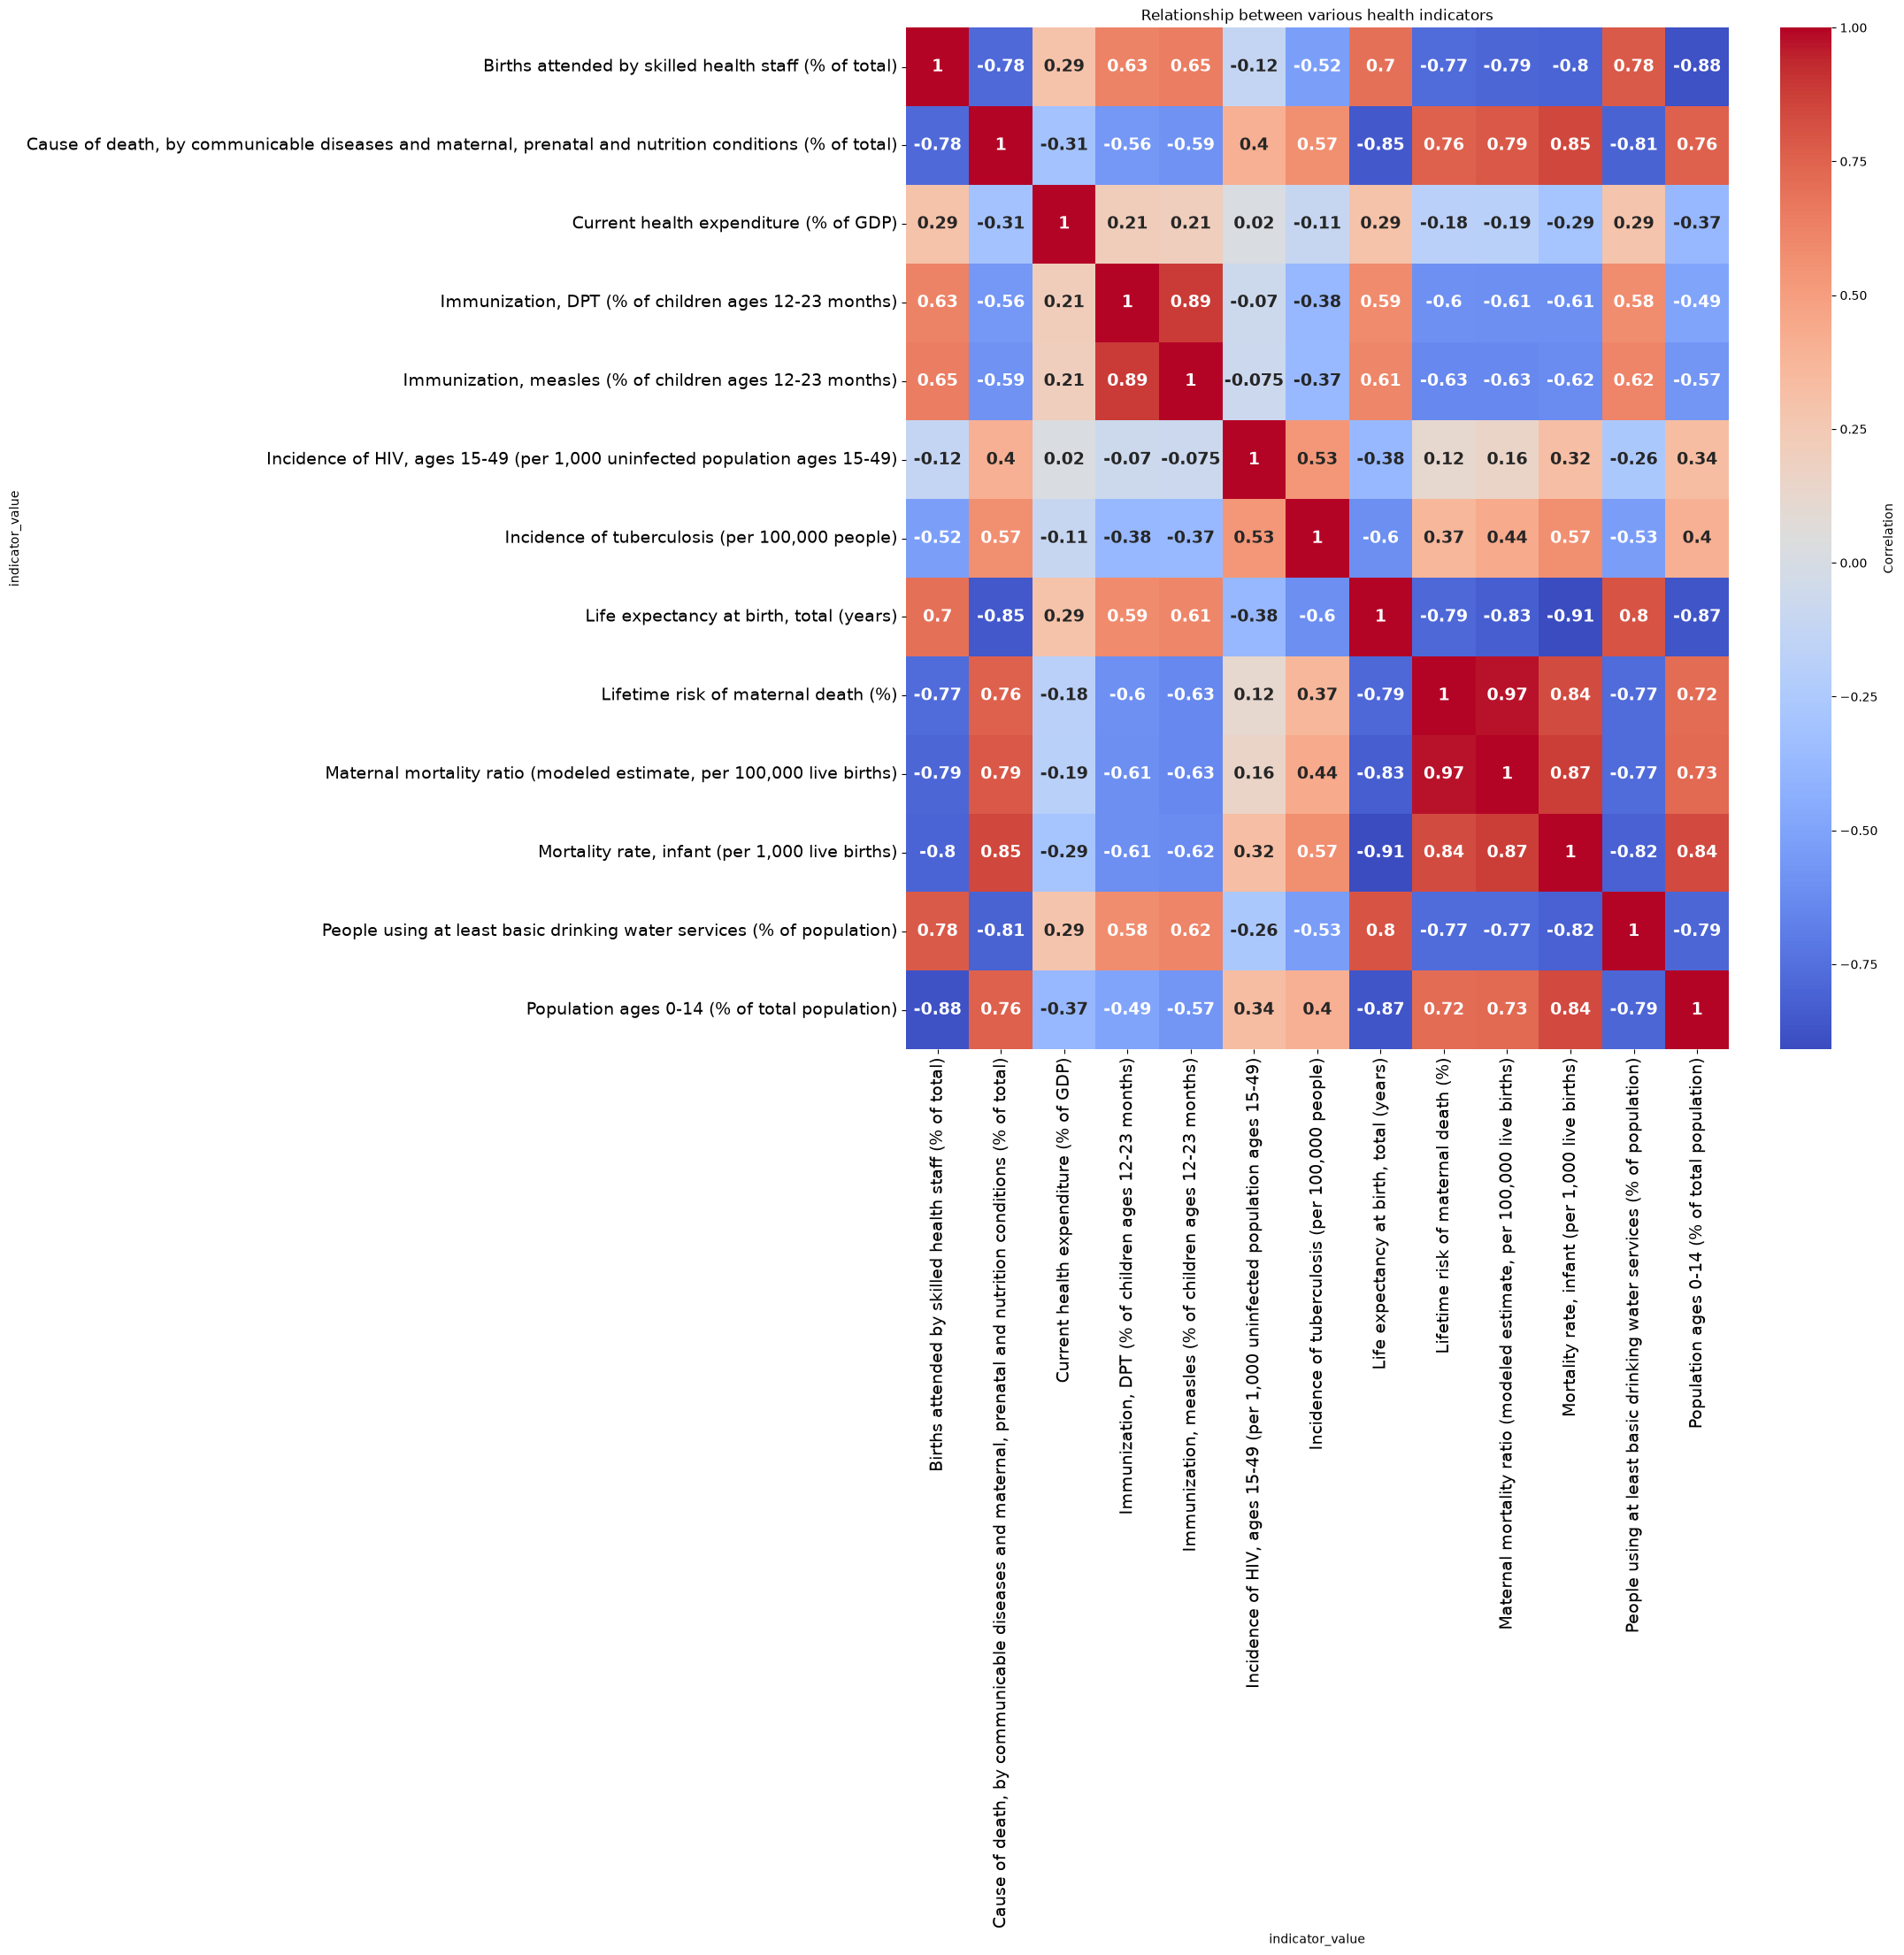

In [229]:
df_wide=health.pivot_table(index=['country_value','year'],columns='indicator_value',values='value')

corr=df_wide.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15), facecolor="white")

ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    cbar_kws={"label": "Correlation"},
    annot_kws={"fontsize": 14, "fontweight": "bold"}
)

plt.title("Relationship between various health indicators")

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.show()

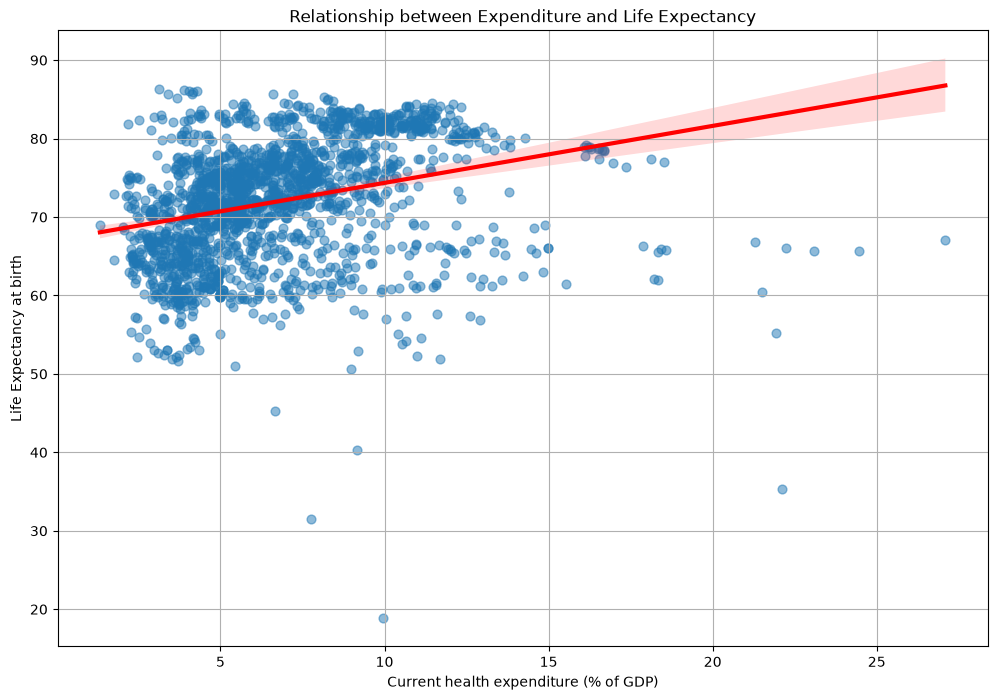

In [232]:
df_pivot = health.pivot(index=["country_value", "year"],columns="indicator_value",values="value").reset_index()

plt.figure(figsize=(12, 8), facecolor="white")

ax = sns.regplot(
    data=df_pivot,
    x="Current health expenditure (% of GDP)",
    y="Life expectancy at birth, total (years)",
    scatter_kws={"alpha": 0.5, "s": 40},
    line_kws={"color": "red", "lw": 3}
)

plt.title("Relationship between Expenditure and Life Expectancy")
plt.xlabel("Current health expenditure (% of GDP)")
plt.ylabel("Life Expectancy at birth")
plt.grid(True)
plt.show()